In [ ]:
#day_1 16-06-2026 20 mins
#day_2 17-06-2026 30 mins
#day_3 22-06-2026 30 mins
#day_4 29-06-2026 25 mins
#day_5 30-06-2026 25 mins
#day_6 09-06-2026 65 mins
20+30+30+25+25+65
# bug: 1. ca is numerical

# 1.printed the data columns
# 2.printted the shape
# 3.checked duplicate
# 4.checked missing value
# 5.catgorized numerical and categorial
# 6.plotted histogram for all numerical numerical_features
# 7.plotted bar chart for categorical features
# 8.checked distribution of target class
# 9.plotted boxplot for outliers for numerical
# 10. did bivariate analysis for numerical vs target
# 11. did bivariate analysis for categorical vs target
# 12. checked correleation for numerical feature date 17/06/2026
# 13. handled misssing value in category with mode
# 14. handled outliers, checked count using IQR, handled with Winsorization (Cap Extreme Values)
# 15. handled target category date
# 16. One hot encoding 22/06/2026
# 17. feature engineering created 5 features
# 18. train test split
# 19. feature scaling 29-06-2026
# 20. logistic regression training and metrics .89 accuracy
# 21. paramater tunning using random search
# 22. training using best params
# 23. .91 using best params
# 24. trained random forrest
# 25. .90 without tunning random forrest
# 26. feature importance in random forrest and visualization 30-06-2026
# 27. 

195

In [2]:
#import dataset
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [4]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [5]:
y.head()

,num
0,0
1,2
2,1
3,0
4,0


In [6]:
X.shape



(303, 13)

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [8]:
#check missing values
X.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
#check the duplicate
X.duplicated().sum()

np.int64(0)

In [10]:
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [11]:
# list all categorical fetaure
categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal'
]

# list all numnerical feature
numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    "ca"
]

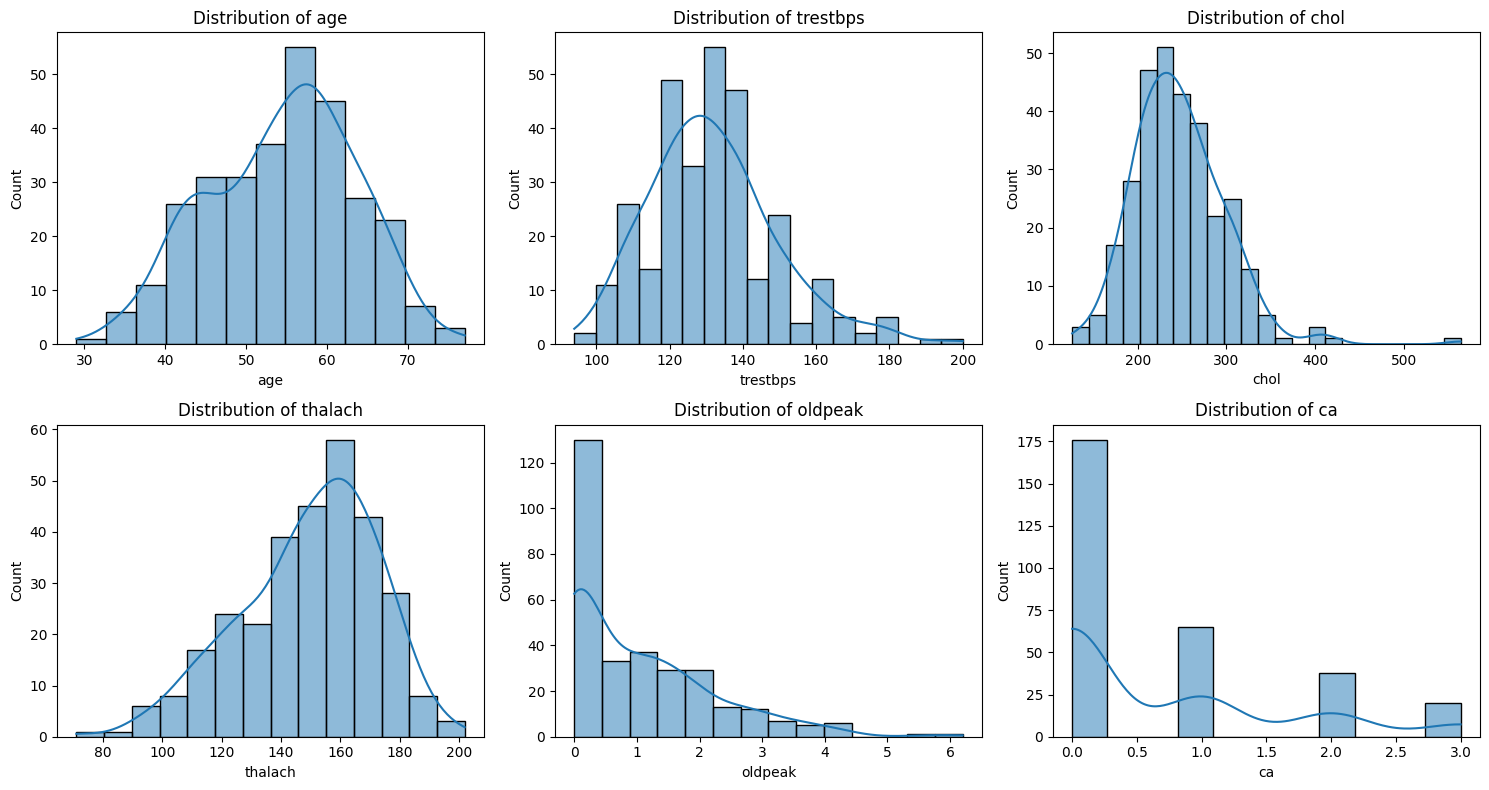

In [12]:
#plotting histogram for numerical features
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(X[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

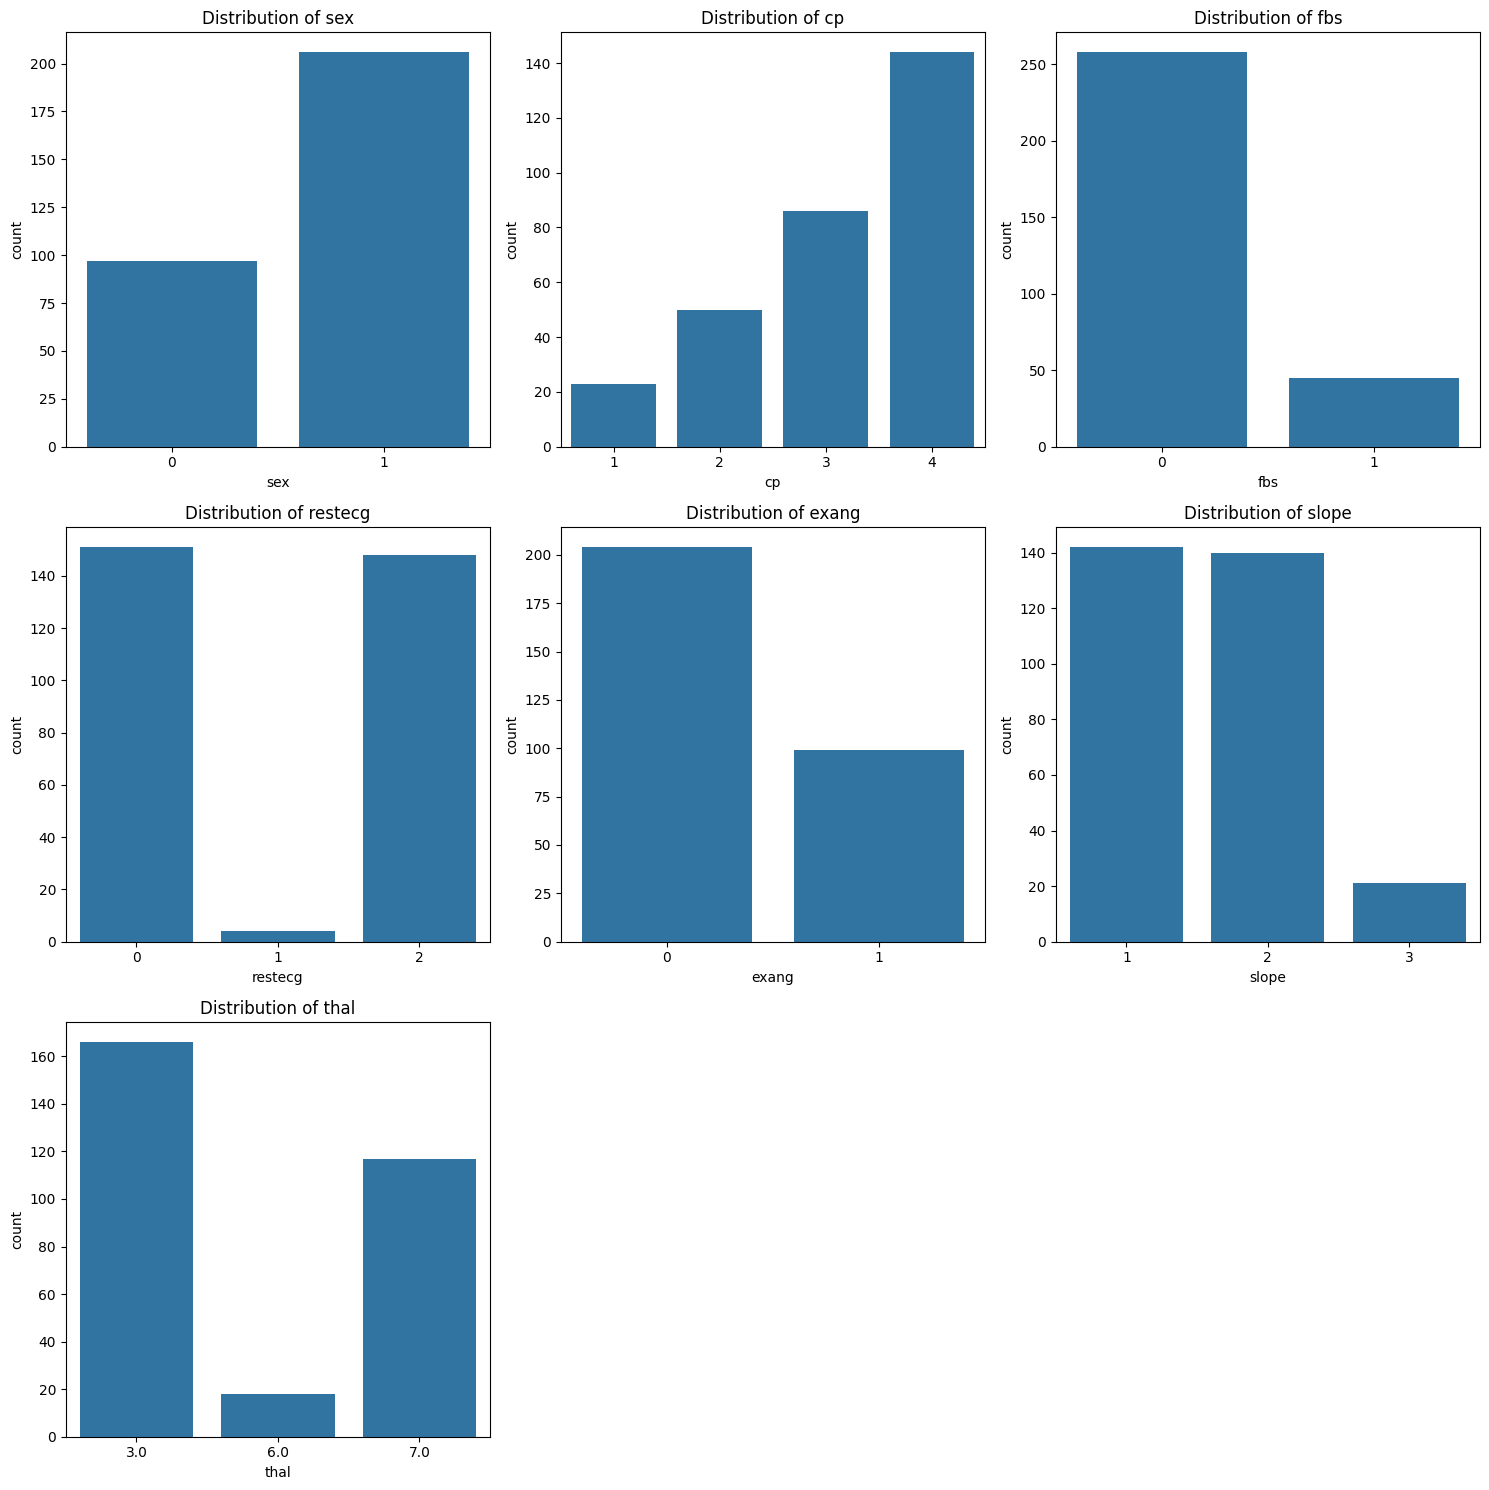

In [13]:
#plotting bar chart for categorical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=X, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<Axes: xlabel='num', ylabel='count'>

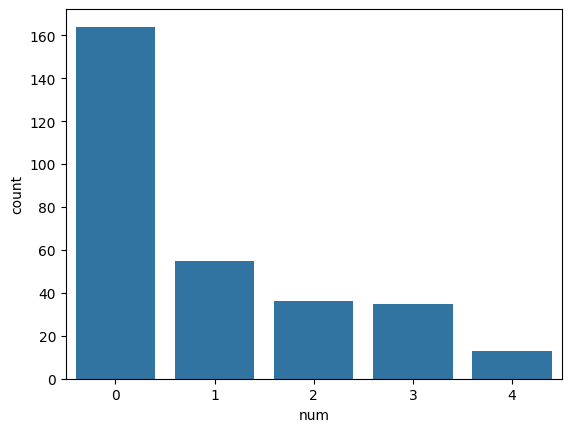

In [14]:
#target class distribution
sns.countplot(x='num', data=y)

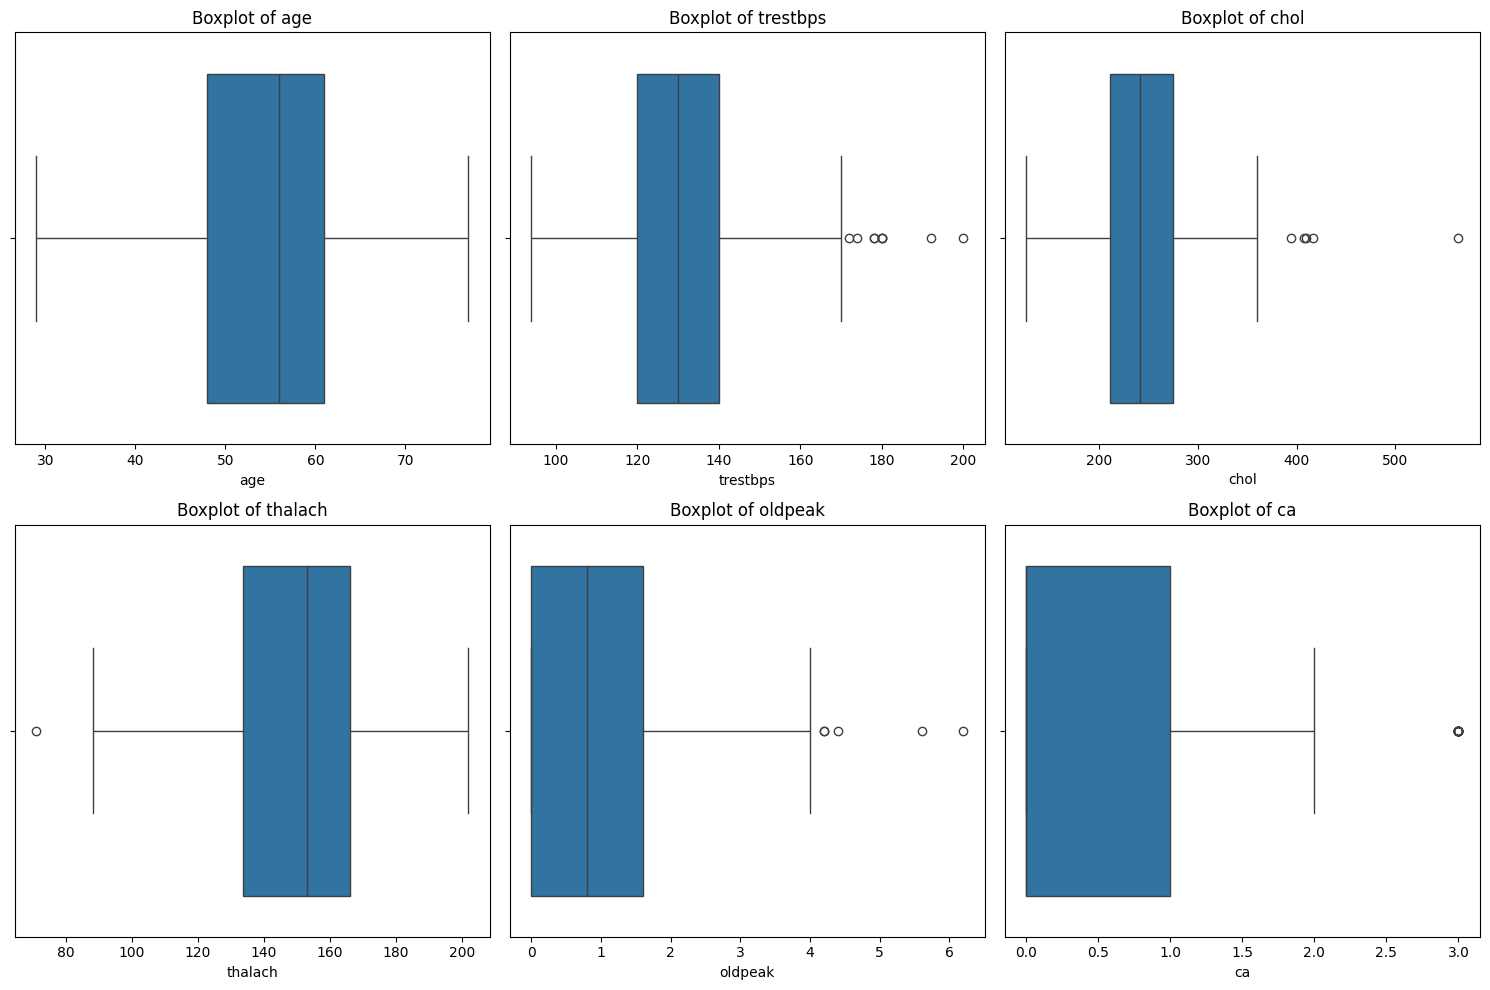

In [15]:
#plotting boxplot for outliers
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=X[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

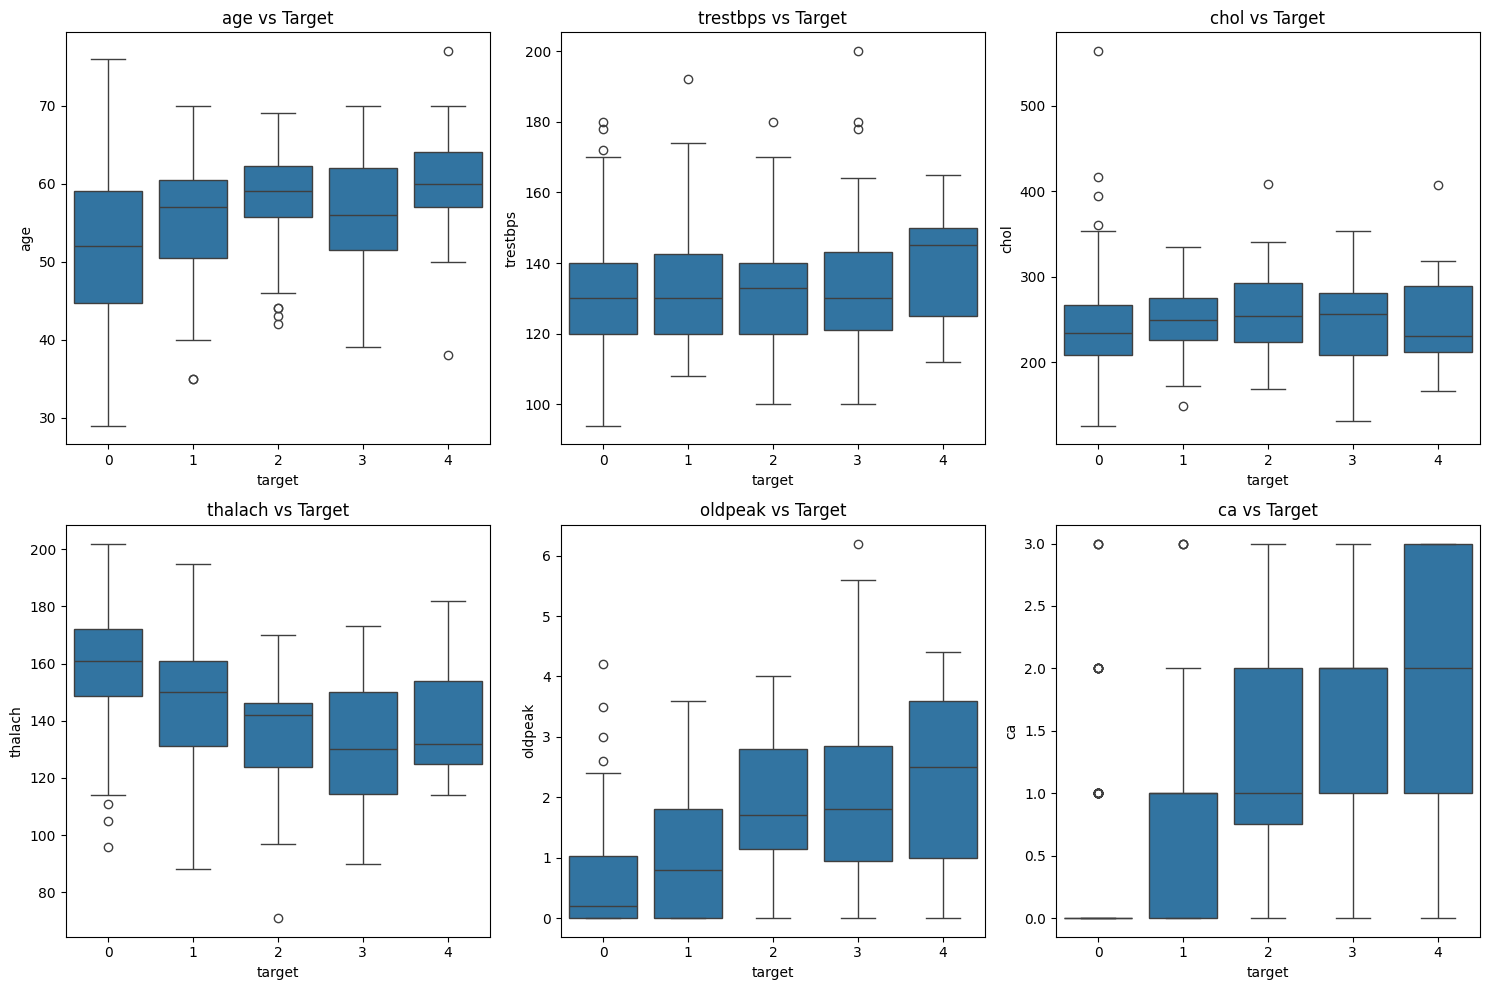

In [16]:
#bivariate analysis numerical vs target
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Combine X and y
df_plot = X.copy()
df_plot['target'] = y

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x='target', y=col, data=df_plot, ax=axes[i])
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

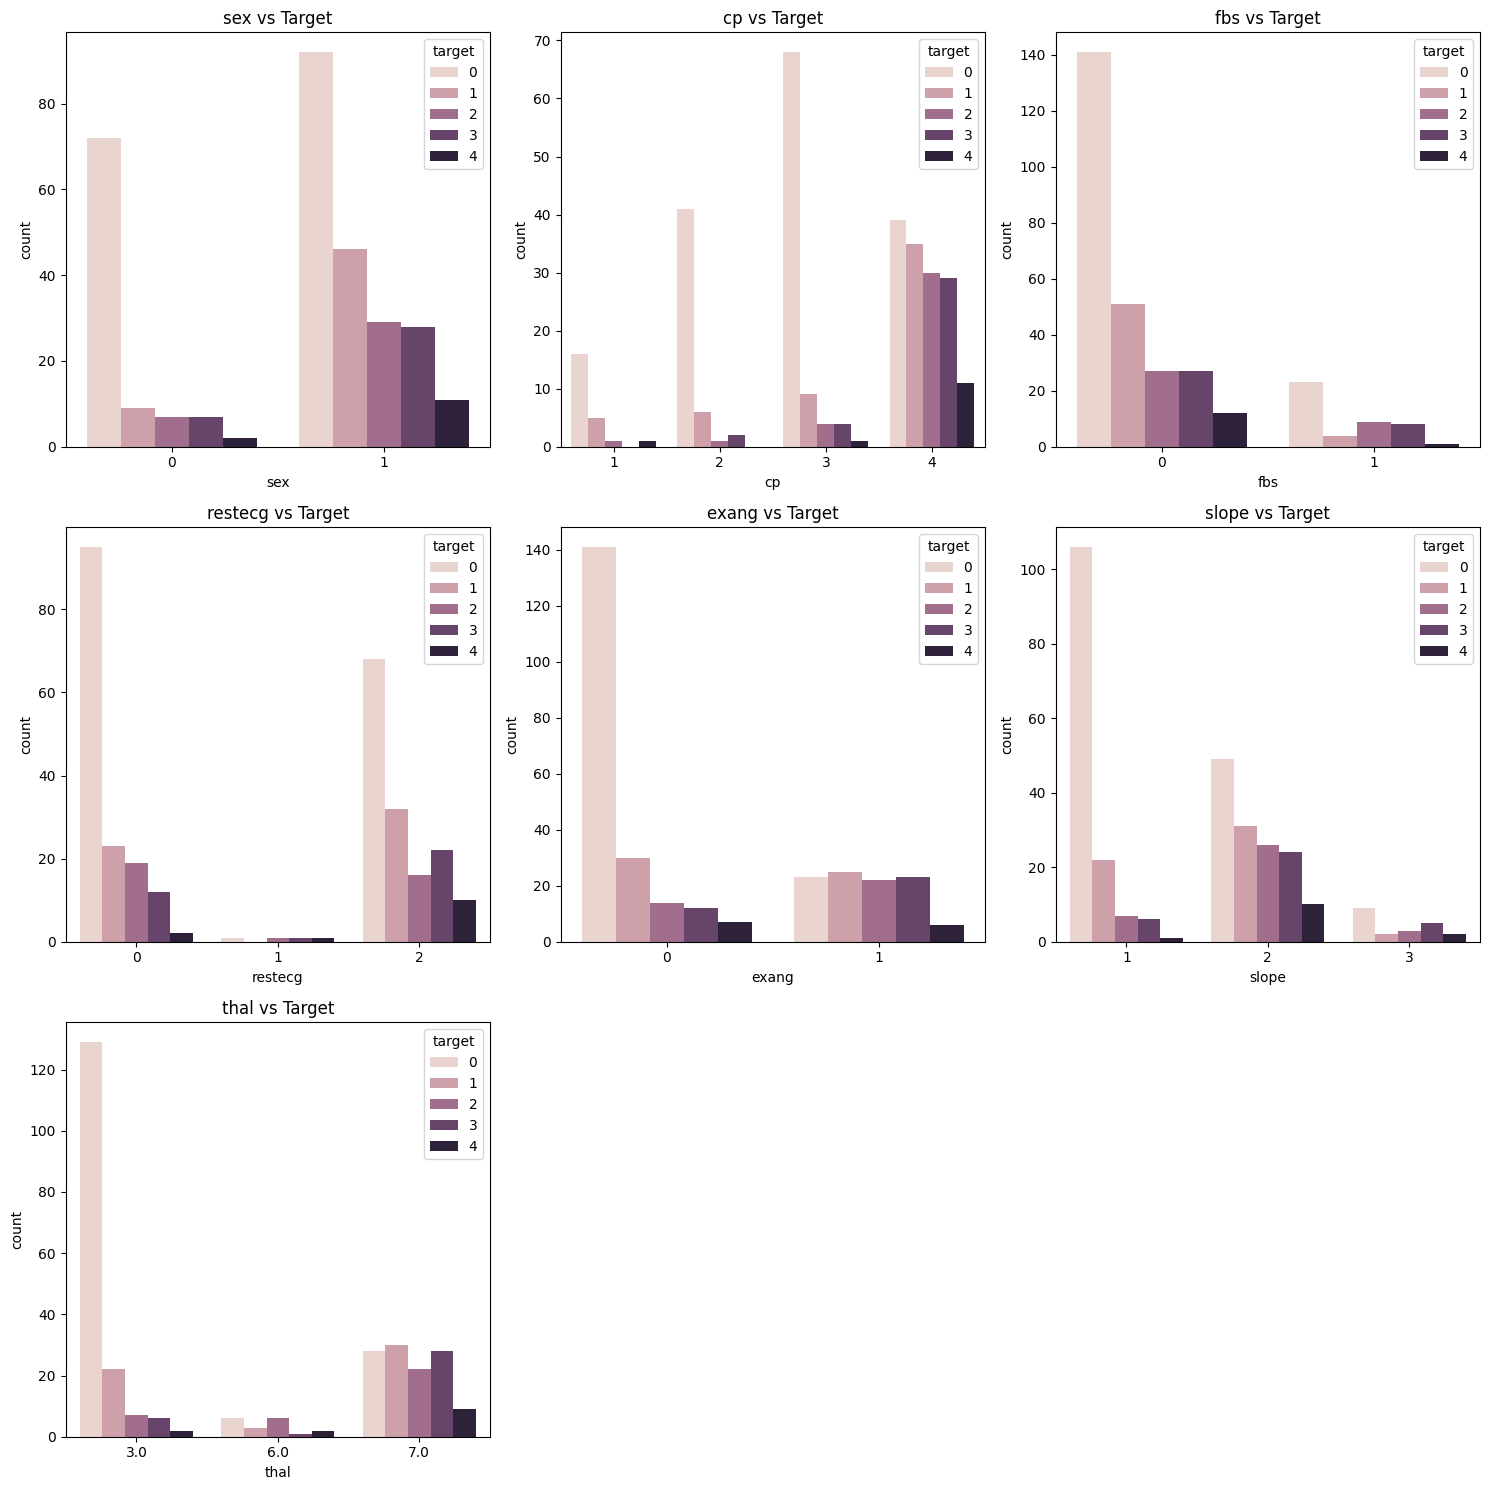

In [17]:
#bivariate for categorical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        x=col,
        hue='target',
        data=df_plot,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Target')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

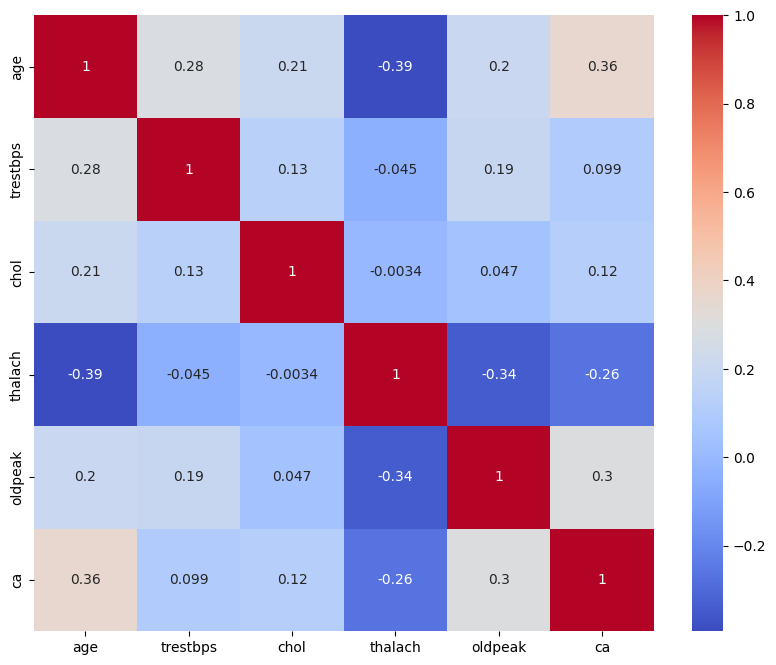

In [18]:
#Correlation Analysis (Numerical Features)
plt.figure(figsize=(10,8))
sns.heatmap(X[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.show()

#Phase 2: Data Preprocessing

In [19]:
# handling missong value
X.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [20]:

# Fill missing values with mode
X = X.copy()

X['ca'] = X['ca'].fillna(X['ca'].mode()[0])
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])
# Verify
X.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [21]:
# Handling  Outliers
for col in numerical_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower) | (X[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 5 outliers
ca: 20 outliers


In [22]:
X[numerical_features].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604,0.663366
std,9.038662,17.599748,51.776918,22.875003,1.161075,0.934375
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000,0.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000


In [23]:
# Winsorization (Cap Extreme Values) for outliers
for col in numerical_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X[col] = X[col].clip(lower, upper)

In [24]:
#check again if any outliers
for col in numerical_features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower) | (X[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
trestbps: 0 outliers
chol: 0 outliers
thalach: 0 outliers
oldpeak: 0 outliers
ca: 0 outliers


In [25]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150.0,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108.0,1,1.5,2,2.5,3.0
2,67,1,4,120,229,0,2,129.0,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187.0,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172.0,0,1.4,1,0.0,3.0


In [26]:
#feature engineering
# Heart Rate Utilization
X['hr_utilization'] = X['thalach'] / (220 - X['age'])

# Exercise Risk
X['exercise_risk'] = X['exang'] * X['oldpeak']

# Age × ST Depression
X['age_oldpeak'] = X['age'] * X['oldpeak']

# High Blood Pressure Flag
X['high_bp'] = (X['trestbps'] >= 140).astype(int)

# High Cholesterol Flag
X['high_chol'] = (X['chol'] >= 240).astype(int)

In [27]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hr_utilization,exercise_risk,age_oldpeak,high_bp,high_chol
0,63,1,1,145,233,1,2,150.0,0,2.3,3,0.0,6.0,0.955414,0.0,144.9,1,0
1,67,1,4,160,286,0,2,108.0,1,1.5,2,2.5,3.0,0.705882,1.5,100.5,1,1
2,67,1,4,120,229,0,2,129.0,1,2.6,2,2.0,7.0,0.843137,2.6,174.2,0,0
3,37,1,3,130,250,0,0,187.0,0,3.5,3,0.0,3.0,1.021858,0.0,129.5,0,1
4,41,0,2,130,204,0,2,172.0,0,1.4,1,0.0,3.0,0.960894,0.0,57.4,0,0


In [28]:
# Feature Encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

X_encoded.head()

,age,trestbps,chol,thalach,oldpeak,ca,hr_utilization,exercise_risk,age_oldpeak,high_bp,...,cp_3,cp_4,fbs_1,restecg_1,restecg_2,exang_1,slope_2,slope_3,thal_6.0,thal_7.0
0,63,145,233,150.0,2.3,0.0,0.955414,0.0,144.9,1,...,False,False,True,False,True,False,False,True,True,False
1,67,160,286,108.0,1.5,2.5,0.705882,1.5,100.5,1,...,False,True,False,False,True,True,True,False,False,False
2,67,120,229,129.0,2.6,2.0,0.843137,2.6,174.2,0,...,False,True,False,False,True,True,True,False,False,True
3,37,130,250,187.0,3.5,0.0,1.021858,0.0,129.5,0,...,True,False,False,False,False,False,False,True,False,False
4,41,130,204,172.0,1.4,0.0,0.960894,0.0,57.4,0,...,False,False,False,False,True,False,False,False,False,False


In [29]:
bool_cols = X_encoded.select_dtypes(include='bool').columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

In [30]:
X_encoded

,age,trestbps,chol,thalach,oldpeak,ca,hr_utilization,exercise_risk,age_oldpeak,high_bp,...,cp_3,cp_4,fbs_1,restecg_1,restecg_2,exang_1,slope_2,slope_3,thal_6.0,thal_7.0
0,63,145,233,150.0,2.3,0.0,0.955414,0.0,144.9,1,...,0,0,1,0,1,0,0,1,1,0
1,67,160,286,108.0,1.5,2.5,0.705882,1.5,100.5,1,...,0,1,0,0,1,1,1,0,0,0
2,67,120,229,129.0,2.6,2.0,0.843137,2.6,174.2,0,...,0,1,0,0,1,1,1,0,0,1
3,37,130,250,187.0,3.5,0.0,1.021858,0.0,129.5,0,...,1,0,0,0,0,0,0,1,0,0
4,41,130,204,172.0,1.4,0.0,0.960894,0.0,57.4,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,110,264,132.0,1.2,0.0,0.754286,0.0,54.0,0,...,0,0,0,0,0,0,1,0,0,1
299,68,144,193,141.0,3.4,2.0,0.927632,0.0,231.2,1,...,0,1,1,0,0,0,1,0,0,1
300,57,130,131,115.0,1.2,1.0,0.705521,1.2,68.4,0,...,0,1,0,0,0,1,1,0,0,1
301,57,130,236,174.0,0.0,1.0,1.067485,0.0,0.0,0,...,0,0,0,0,1,0,1,0,0,0


In [31]:
y = (y > 0).astype(int)
y.head()

,num
0,0
1,1
2,1
3,0
4,0


In [32]:
#train test split
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#doing train test split before scaling to avoid data leakage


X_train shape: (242, 23)
X_test shape: (61, 23)
y_train shape: (242, 1)
y_test shape: (61, 1)


In [33]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Numerical columns
numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    "hr_utilization",
    "exercise_risk",
    "age_oldpeak"
]

# Scale only on training data
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)


In [34]:
X_train.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'hr_utilization',
       'exercise_risk', 'age_oldpeak', 'high_bp', 'high_chol', 'sex_1', 'cp_2',
       'cp_3', 'cp_4', 'fbs_1', 'restecg_1', 'restecg_2', 'exang_1', 'slope_2',
       'slope_3', 'thal_6.0', 'thal_7.0'],
      dtype='object')

In [35]:
#feature selection
# there are very less features so no need to do feature selection


In [36]:
# training

#Logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

[[28  5]
 [ 2 26]]


In [38]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15}
0.8179421768707481


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [39]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9180327868852459
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        33
           1       0.90      0.93      0.91        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [40]:
# Random forrest
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9016393442622951

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        33
           1       0.89      0.89      0.89        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


Confusion Matrix:
[[30  3]
 [ 3 25]]


In [42]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

           Feature  Importance
5               ca    0.101758
22        thal_7.0    0.090004
3          thalach    0.088200
6   hr_utilization    0.086285
14            cp_4    0.073766
8      age_oldpeak    0.071651
2             chol    0.066328
4          oldpeak    0.061659
1         trestbps    0.060279
0              age    0.059383
7    exercise_risk    0.053354
18         exang_1    0.035577
11           sex_1    0.034426
19         slope_2    0.034061
13            cp_3    0.017517
17       restecg_2    0.013816
10       high_chol    0.012719
9          high_bp    0.010409
12            cp_2    0.009806
15           fbs_1    0.008711
21        thal_6.0    0.005341
20         slope_3    0.004711
16       restecg_1    0.000240


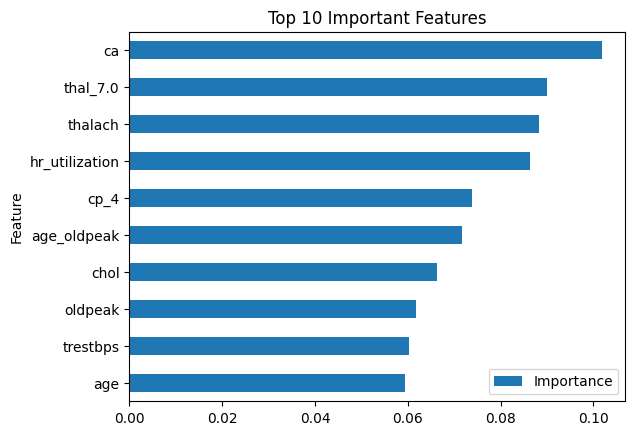

In [43]:
import matplotlib.pyplot as plt

importance_df.head(10).sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title("Top 10 Important Features")
plt.show()

In [50]:
import matplotlib.pyplot as plt

# Your plotting code
plt.figure(figsize=(10, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])

plt.savefig("feature_importance.png")
plt.close()

mlflow.log_artifact("feature_importance.png")

In [51]:
# !pip install mlflow

In [56]:
#mlflow integration
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

with mlflow.start_run():

    y_pred = best_rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])

    mlflow.log_param("model","RandomForest")
    mlflow.log_param("n_estimators",200)

    mlflow.log_metric("accuracy",acc)
    mlflow.log_metric("precision",precision)
    mlflow.log_metric("recall",recall)
    mlflow.log_metric("roc_auc",roc_auc)

    mlflow.sklearn.log_model(best_rf,"heart_model")

print("MLflow logging completed")

2026/07/09 13:20:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow logging completed


In [57]:
mlflow.end_run()

In [62]:
#saving model
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_rf, "models/heart_disease_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/heart_disease_model.pkl']

In [61]:
#fast api implemenation
from fastapi import FastAPI
import pandas as pd
import joblib

app = FastAPI()

model = joblib.load("models/heart_disease_model.pkl")

@app.get("/")
def home():
    return {"message":"Heart Disease Prediction API"}

@app.post("/predict")
def predict(data: dict):

    df = pd.DataFrame([data])

    prediction = model.predict(df)[0]

    confidence = model.predict_proba(df).max()

    return {
        "prediction": int(prediction),
        "confidence": float(confidence)
    }